In [4]:
# titulo aplicación fr DIKW para el dataset titanic
# objetivo : identificar las diferentes capas frl modelo dikw en proceso ETL
# fecha 21 mayo

import pandas as pd

In [5]:
# pip install matplotlib seaborn

In [6]:
import matplotlib.pyplot as plt


In [7]:
import seaborn as sns

In [8]:
df = pd.read_csv("test.csv")

In [9]:
# mostrar nulos y datos de las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [10]:
# mostrar 3 primeros
df.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [11]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [12]:
# ver las columnas
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [13]:
#limpieza
#columnas en minusculas
df.columns = df.columns.str.strip().str.lower()

In [14]:
# detectar valores nulos
df.isnull().sum()

passengerid      0
pclass           0
name             0
sex              0
age             86
sibsp            0
parch            0
ticket           0
fare             1
cabin          327
embarked         0
dtype: int64

In [15]:
#eliminamos la columna cabin pues tiene muchos null

df.drop(columns=["cabin"],inplace=True)

In [16]:
#verificamos que se elimino 
df.columns

Index(['passengerid', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'embarked'],
      dtype='str')

In [17]:
#rellenamos los pocos vacios , en este caso la edad, con la edad media
df["age"] = df["age"].fillna(df["age"].median()) 

In [18]:
# detectar valores nulos
df.isnull().sum()

passengerid    0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           1
embarked       0
dtype: int64

In [19]:
#rellenamos el fare con el valor q mas se repite (la moda)
df["fare"] = df["fare"].fillna(df["fare"].mode()[0])

In [20]:
# detectar valores nulos
df.isnull().sum()

passengerid    0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
embarked       0
dtype: int64

In [21]:
#valores duplicados

df.duplicated().sum()

np.int64(0)

In [25]:
#valdiar datos
df["age"].min()

np.float64(0.17)

In [26]:
#valdiar datos
df["age"].max()

np.float64(76.0)

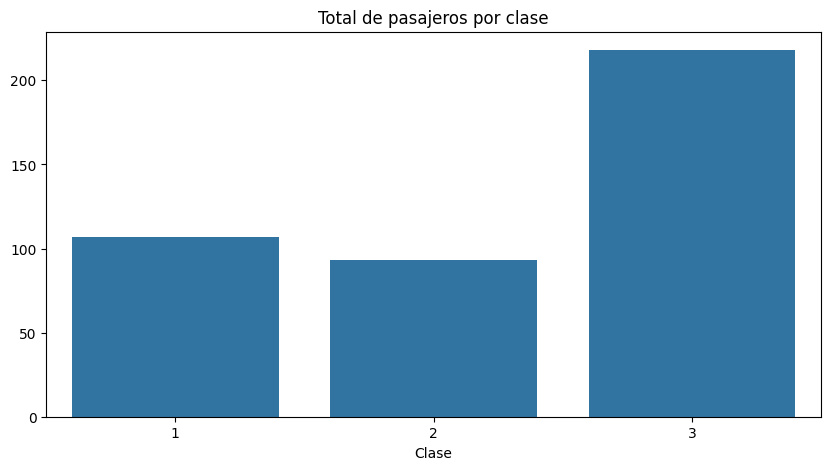

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(df,x="pclass")
plt.title("Total de pasajeros por clase")
plt.xlabel("Clase")
plt.ylabel("")
plt.show()

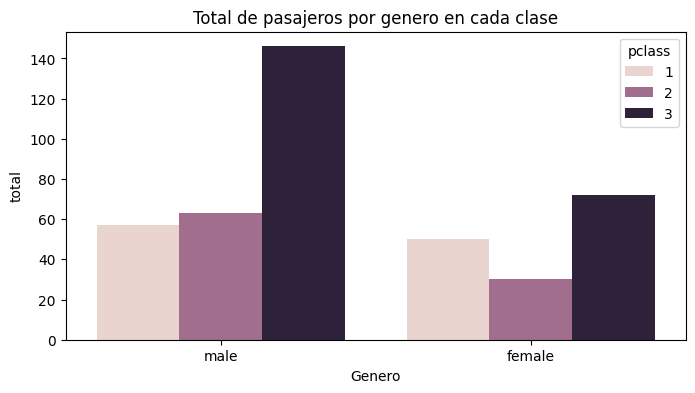

In [32]:
# graficamos las clases por genero

plt.figure(figsize=(8,4))

sns.countplot(df,x="sex", hue="pclass") # 

plt.title("Total de pasajeros por genero en cada clase")
plt.xlabel("Genero")
plt.ylabel("total")

plt.show()

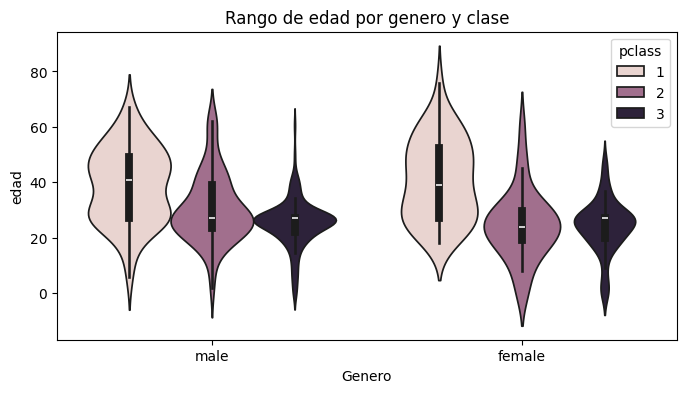

In [34]:
# edad por genero y clase 
plt.figure(figsize=(8,4))

sns.violinplot(df,x="sex", y="age", hue="pclass") 

plt.title("Rango de edad por genero y clase")
plt.xlabel("Genero")
plt.ylabel("edad")

plt.show()

In [39]:
# la 1a clase pagaba mas
df.groupby("pclass")["fare"].mean()

pclass
1    94.280297
2    22.202104
3    12.438074
Name: fare, dtype: float64

In [40]:
#la distribucion muestra que habia mas hombres que mujeres
df["sex"].value_counts()

sex
male      266
female    152
Name: count, dtype: int64